# 📚 Klasifikasi Survei Penggunaan Platform Belajar Online pada Mahasiswa
> **Tujuan:** Mengklasifikasikan tingkat kepuasan mahasiswa (Rendah / Sedang / Tinggi) berdasarkan pola penggunaan platform belajar online.  
> **Algoritma:** Decision Tree · K-Nearest Neighbor (KNN) · Random Forest · Naive Bayes  
> **Dataset:** `Survei-Penggunaan-Platform-Belajar-Online-pada-Mahasiswa.csv`

## 1. Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print('✅ Library berhasil diimport')

✅ Library berhasil diimport


## 2. Load Dataset

In [3]:
df = pd.read_csv('Survei Penggunaan Platform Belajar Online pada Mahasiswa.csv')
print(f'Jumlah data: {df.shape[0]} baris, {df.shape[1]} kolom')
df.head()

Jumlah data: 104 baris, 14 kolom


,Cap waktu,Nama lengkap,Asal universitas (cantumkan nama lengkap),Jurusan / program studi,Angkatan,Usia Anda?,Status/aktivitas utama Anda saat ini?,Platform Utama belajar online yang paling sering Anda gunakan?,Perangkat yang paling sering Anda gunakan untuk belajar online?,Rata-rata berapa jam per minggu Anda menggunakan platform belajar online?,Tujuan utama Anda menggunakan platform belajar online?,Jenis materi yang paling Anda sukai saat belajar online?,"Menurut Anda, berapa persentase materi/kursus/modul yang biasanya Anda selesaikan?",Seberapa puas Anda terhadap platform belajar online yang paling sering Anda gunakan?
0,2026/04/08 10:24:53 PM GMT+7,Fizar Erlansyah,Universitas Pembangunan Jaya,Sistem Informasi,2024,18–24 tahun,Mahasiswa/pelajar,YouTube,Laptop,1–3 jam,Pengembangan karier,Campuran keduanya,81–100%,7
1,2026/04/08 10:27:49 PM GMT+7,Muhammad Rayhan Mumtaz,Universitas Pembangunan Jaya,Sistem Informasi,2024,18–24 tahun,Mahasiswa/pelajar,YouTube,Laptop,4–6 jam,Keperluan akademik,Campuran keduanya,81–100%,8
2,2026/04/08 10:28:25 PM GMT+7,Panji Kurnia Akbar,Universitas Pembangunan Jaya,Sistem Informasi,2024,18–24 tahun,Mahasiswa/pelajar,YouTube,Laptop,4–6 jam,Upgrade skill,Video,81–100%,8
3,2026/04/08 10:31:24 PM GMT+7,Azkiyah zhafirah,Universitas Pancasila,Farmasi,2025,18–24 tahun,Mahasiswa/pelajar,YouTube,HP / Mobile,7–10 jam,Keperluan akademik,Campuran keduanya,41–60%,7
4,2026/04/08 10:32:41 PM GMT+7,zavira verga,Universitas Pembangunan Jaya,accounting,2025,18–24 tahun,Mahasiswa/pelajar,YouTube,Laptop,Lebih dari 20 jam,Keperluan akademik,Video,81–100%,9


## 3. Preprocessing Data

### 3.1 Seleksi & Rename Kolom

In [4]:
col_map = {
    'Usia Anda?': 'usia',
    'Status/aktivitas utama Anda saat ini?': 'status',
    'Platform Utama belajar online yang paling sering Anda gunakan?': 'platform',
    'Perangkat yang paling sering Anda gunakan untuk belajar online?': 'perangkat',
    'Rata-rata berapa jam per minggu Anda menggunakan platform belajar online?': 'jam_belajar',
    'Tujuan utama Anda menggunakan platform belajar online?': 'tujuan',
    'Jenis materi yang paling Anda sukai saat belajar online?': 'jenis_materi',
    'Menurut Anda, berapa persentase materi/kursus/modul yang biasanya Anda selesaikan?': 'persentase_selesai',
    'Seberapa puas Anda terhadap platform belajar online yang paling sering Anda gunakan?': 'kepuasan'
}

df_clean = df[list(col_map.keys())].rename(columns=col_map).copy()
print('Kolom setelah rename:')
print(df_clean.columns.tolist())
df_clean.head()

Kolom setelah rename:
['usia', 'status', 'platform', 'perangkat', 'jam_belajar', 'tujuan', 'jenis_materi', 'persentase_selesai', 'kepuasan']


,usia,status,platform,perangkat,jam_belajar,tujuan,jenis_materi,persentase_selesai,kepuasan
0,18–24 tahun,Mahasiswa/pelajar,YouTube,Laptop,1–3 jam,Pengembangan karier,Campuran keduanya,81–100%,7
1,18–24 tahun,Mahasiswa/pelajar,YouTube,Laptop,4–6 jam,Keperluan akademik,Campuran keduanya,81–100%,8
2,18–24 tahun,Mahasiswa/pelajar,YouTube,Laptop,4–6 jam,Upgrade skill,Video,81–100%,8
3,18–24 tahun,Mahasiswa/pelajar,YouTube,HP / Mobile,7–10 jam,Keperluan akademik,Campuran keduanya,41–60%,7
4,18–24 tahun,Mahasiswa/pelajar,YouTube,Laptop,Lebih dari 20 jam,Keperluan akademik,Video,81–100%,9


### 3.2 Konversi Kolom Ordinal ke Numerik

In [5]:
jam_map = {
    '< 1 jam': 0.5, '1\u20133 jam': 2.0, '4\u20136 jam': 5.0,
    '7\u201310 jam': 8.5, '11\u201315 jam': 13.0,
    '16\u201320 jam': 18.0, 'Lebih dari 20 jam': 22.0
}

persen_map = {
    '0\u201320%': 10, '21\u201340%': 30, '41\u201360%': 50,
    '61\u201380%': 70, '81\u2013100%': 90
}

df_clean['jam_belajar_num'] = df_clean['jam_belajar'].map(jam_map)
df_clean['persentase_selesai_num'] = df_clean['persentase_selesai'].map(persen_map)

print('Cek missing value setelah mapping:')
print(df_clean[['jam_belajar_num', 'persentase_selesai_num']].isnull().sum())

Cek missing value setelah mapping:
jam_belajar_num           0
persentase_selesai_num    0
dtype: int64


### 3.3 Membuat Label Kelas Kepuasan

In [6]:
# Kepuasan skala 1-10 -> 3 kelas
# Rendah : 1-4
# Sedang : 5-7
# Tinggi : 8-10

def label_kepuasan(nilai):
    if nilai <= 4:
        return 'Rendah'
    elif nilai <= 7:
        return 'Sedang'
    else:
        return 'Tinggi'

df_clean['kelas_kepuasan'] = df_clean['kepuasan'].apply(label_kepuasan)

print('Distribusi Kelas Kepuasan:')
print(df_clean['kelas_kepuasan'].value_counts())
print(f'\nTotal data: {len(df_clean)}')

Distribusi Kelas Kepuasan:
kelas_kepuasan
Sedang    43
Tinggi    33
Rendah    28
Name: count, dtype: int64

Total data: 104


### 3.4 Label Encoding Fitur Kategorikal

In [7]:
fitur_kategori = ['usia', 'status', 'platform', 'perangkat', 'tujuan', 'jenis_materi']
fitur_numerik  = ['jam_belajar_num', 'persentase_selesai_num']

df_model = df_clean[fitur_kategori + fitur_numerik + ['kelas_kepuasan']].dropna().copy()

# Simpan encoder untuk prediksi data baru
encoders = {}
for col in fitur_kategori:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

# Encode target
le_target = LabelEncoder()
df_model['target'] = le_target.fit_transform(df_model['kelas_kepuasan'])

print('Kelas target:', le_target.classes_)
print(f'Total data valid: {len(df_model)}')
df_model.head()

Kelas target: ['Rendah' 'Sedang' 'Tinggi']
Total data valid: 104


,usia,status,platform,perangkat,tujuan,jenis_materi,jam_belajar_num,persentase_selesai_num,kelas_kepuasan,usia_enc,status_enc,platform_enc,perangkat_enc,tujuan_enc,jenis_materi_enc,target
0,18–24 tahun,Mahasiswa/pelajar,YouTube,Laptop,Pengembangan karier,Campuran keduanya,2.0,90,Sedang,0,1,6,2,2,0,1
1,18–24 tahun,Mahasiswa/pelajar,YouTube,Laptop,Keperluan akademik,Campuran keduanya,5.0,90,Tinggi,0,1,6,2,1,0,2
2,18–24 tahun,Mahasiswa/pelajar,YouTube,Laptop,Upgrade skill,Video,5.0,90,Tinggi,0,1,6,2,3,2,2
3,18–24 tahun,Mahasiswa/pelajar,YouTube,HP / Mobile,Keperluan akademik,Campuran keduanya,8.5,50,Sedang,0,1,6,1,1,0,1
4,18–24 tahun,Mahasiswa/pelajar,YouTube,Laptop,Keperluan akademik,Video,22.0,90,Tinggi,0,1,6,2,1,2,2


## 4. Eksplorasi Data (EDA)

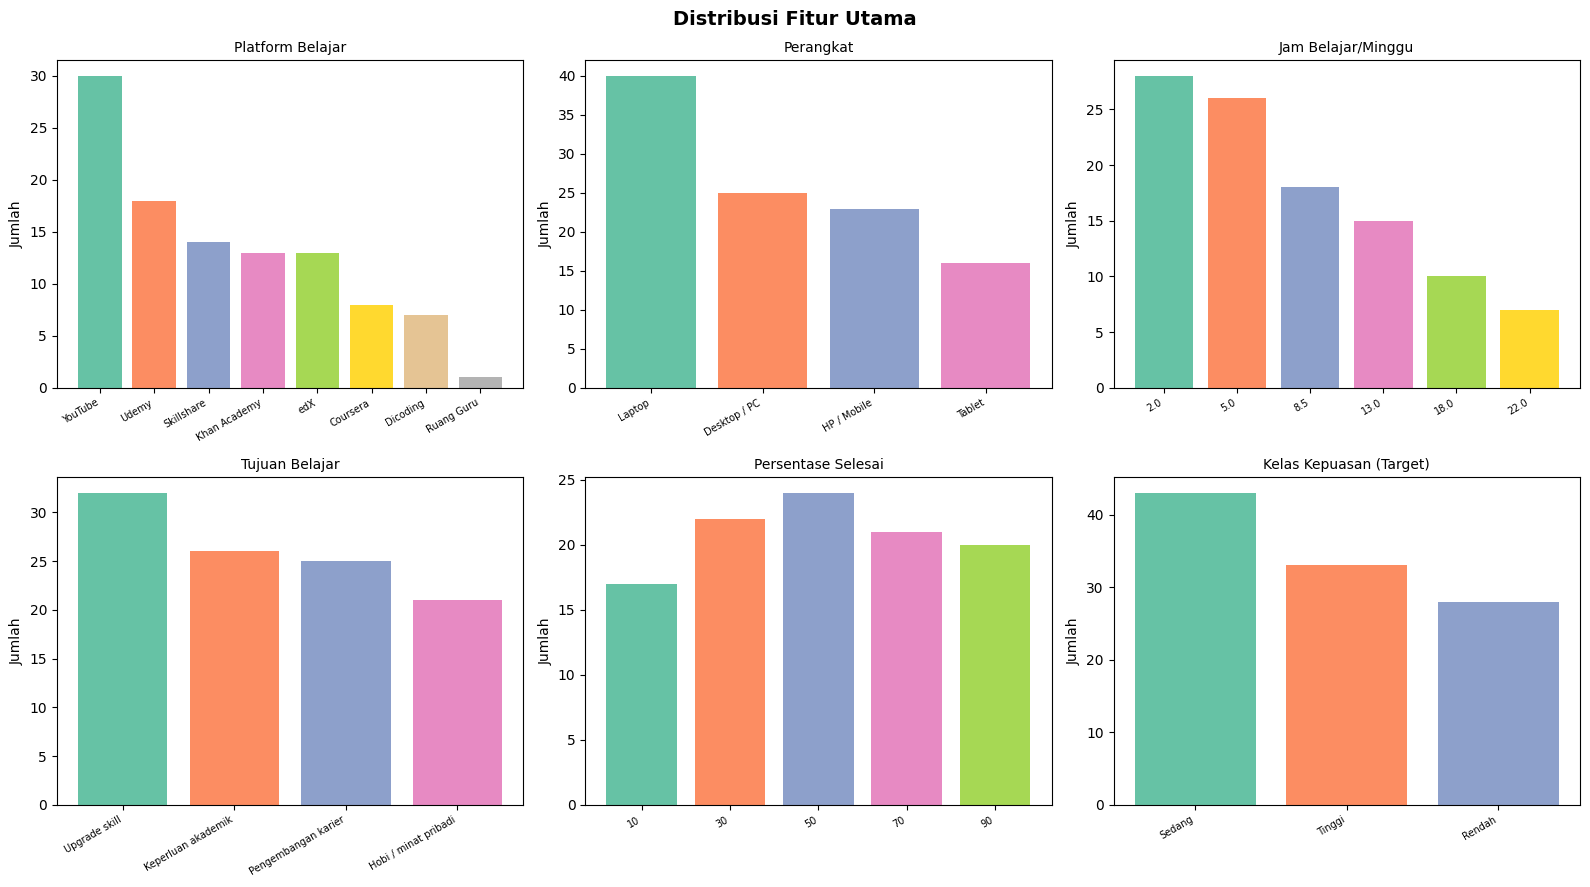

Plot tersimpan: distribusi_fitur.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribusi Fitur Utama', fontsize=14, fontweight='bold')

plot_list = [
    ('platform',           'Platform Belajar',        axes[0, 0]),
    ('perangkat',          'Perangkat',               axes[0, 1]),
    ('jam_belajar',        'Jam Belajar/Minggu',      axes[0, 2]),
    ('tujuan',             'Tujuan Belajar',          axes[1, 0]),
    ('persentase_selesai', 'Persentase Selesai',      axes[1, 1]),
    ('kelas_kepuasan',     'Kelas Kepuasan (Target)', axes[1, 2]),
]

palette = sns.color_palette('Set2', 10)
for col, title, ax in plot_list:
    if col == 'jam_belajar':
      counts = df_model['jam_belajar_num'].value_counts().sort_index()
    elif col == 'persentase_selesai':
      counts = df_model['persentase_selesai_num'].value_counts().sort_index()
    else:
      counts = df_model[col].value_counts()
    ax.bar(range(len(counts)), counts.values, color=palette[:len(counts)])
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=30, ha='right', fontsize=7)
    ax.set_ylabel('Jumlah')

plt.tight_layout()
plt.savefig('distribusi_fitur.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot tersimpan: distribusi_fitur.png')

## 5. Pembagian Data Train / Test

In [9]:
fitur_enc = [col + '_enc' for col in fitur_kategori] + fitur_numerik

X = df_model[fitur_enc]
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Data Train : {X_train.shape[0]} sampel')
print(f'Data Test  : {X_test.shape[0]} sampel')
print(f'Distribusi kelas train: {dict(zip(le_target.classes_, np.bincount(y_train)))}')

Data Train : 83 sampel
Data Test  : 21 sampel
Distribusi kelas train: {'Rendah': np.int64(23), 'Sedang': np.int64(34), 'Tinggi': np.int64(26)}


## 6. Training & Evaluasi Model

### 6.1 Decision Tree

In [10]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f'Akurasi Decision Tree: {acc_dt:.4f} ({acc_dt*100:.2f}%)')
print(classification_report(y_test, y_pred_dt, target_names=le_target.classes_))

Akurasi Decision Tree: 0.2857 (28.57%)
              precision    recall  f1-score   support

      Rendah       0.29      0.40      0.33         5
      Sedang       0.33      0.33      0.33         9
      Tinggi       0.20      0.14      0.17         7

    accuracy                           0.29        21
   macro avg       0.27      0.29      0.28        21
weighted avg       0.28      0.29      0.28        21



### 6.2 K-Nearest Neighbor (KNN)

In [11]:
# Cari K terbaik via Cross Validation
k_scores = []
for k in range(1, 16):
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy').mean()
    k_scores.append((k, score))

best_k, best_score = max(k_scores, key=lambda x: x[1])
print(f'K terbaik: {best_k}  (CV accuracy = {best_score:.4f})')

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f'Akurasi KNN (K={best_k}): {acc_knn:.4f} ({acc_knn*100:.2f}%)')
print(classification_report(y_test, y_pred_knn, target_names=le_target.classes_))

K terbaik: 13  (CV accuracy = 0.5434)
Akurasi KNN (K=13): 0.4286 (42.86%)
              precision    recall  f1-score   support

      Rendah       0.38      0.60      0.46         5
      Sedang       0.44      0.44      0.44         9
      Tinggi       0.50      0.29      0.36         7

    accuracy                           0.43        21
   macro avg       0.44      0.44      0.42        21
weighted avg       0.45      0.43      0.42        21



### 6.3 Random Forest

In [12]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Akurasi Random Forest: {acc_rf:.4f} ({acc_rf*100:.2f}%)')
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))

Akurasi Random Forest: 0.4286 (42.86%)
              precision    recall  f1-score   support

      Rendah       0.40      0.40      0.40         5
      Sedang       0.45      0.56      0.50         9
      Tinggi       0.40      0.29      0.33         7

    accuracy                           0.43        21
   macro avg       0.42      0.41      0.41        21
weighted avg       0.42      0.43      0.42        21



### 6.4 Naive Bayes

In [13]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)
print(f'Akurasi Naive Bayes: {acc_nb:.4f} ({acc_nb*100:.2f}%)')
print(classification_report(y_test, y_pred_nb, target_names=le_target.classes_))

Akurasi Naive Bayes: 0.2857 (28.57%)
              precision    recall  f1-score   support

      Rendah       0.12      0.20      0.15         5
      Sedang       0.38      0.33      0.35         9
      Tinggi       0.40      0.29      0.33         7

    accuracy                           0.29        21
   macro avg       0.30      0.27      0.28        21
weighted avg       0.32      0.29      0.30        21



## 7. Perbandingan Akurasi Model

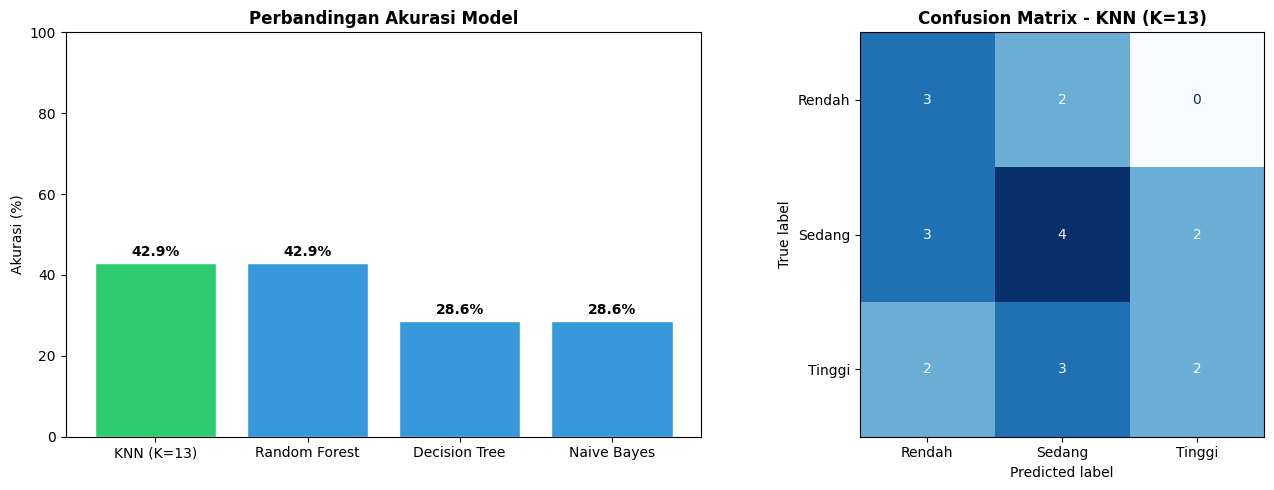


 Tabel Perbandingan Akurasi:
        Model  Accuracy  Accuracy (%)
   KNN (K=13)  0.428571         42.86
Random Forest  0.428571         42.86
Decision Tree  0.285714         28.57
  Naive Bayes  0.285714         28.57

Model Terbaik: KNN (K=13) (42.86%)


In [14]:
hasil = pd.DataFrame({
    'Model': ['Decision Tree', f'KNN (K={best_k})', 'Random Forest', 'Naive Bayes'],
    'Accuracy': [acc_dt, acc_knn, acc_rf, acc_nb]
})
hasil['Accuracy (%)'] = (hasil['Accuracy'] * 100).round(2)
hasil = hasil.sort_values('Accuracy', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(hasil))]
bars = axes[0].bar(hasil['Model'], hasil['Accuracy (%)'], color=colors, edgecolor='white')
axes[0].set_title('Perbandingan Akurasi Model', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Akurasi (%)')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, hasil['Accuracy (%)']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# Confusion matrix model terbaik
best_model_name = hasil.iloc[0]['Model']
pred_map = {
    'Decision Tree': y_pred_dt,
    f'KNN (K={best_k})': y_pred_knn,
    'Random Forest': y_pred_rf,
    'Naive Bayes': y_pred_nb
}
best_pred = pred_map[best_model_name]

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_target.classes_)
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion Matrix - {best_model_name}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n Tabel Perbandingan Akurasi:')
print(hasil.to_string(index=False))
print(f'\nModel Terbaik: {best_model_name} ({hasil.iloc[0]["Accuracy (%)"]:.2f}%)')

## 8. Feature Importance (Random Forest)

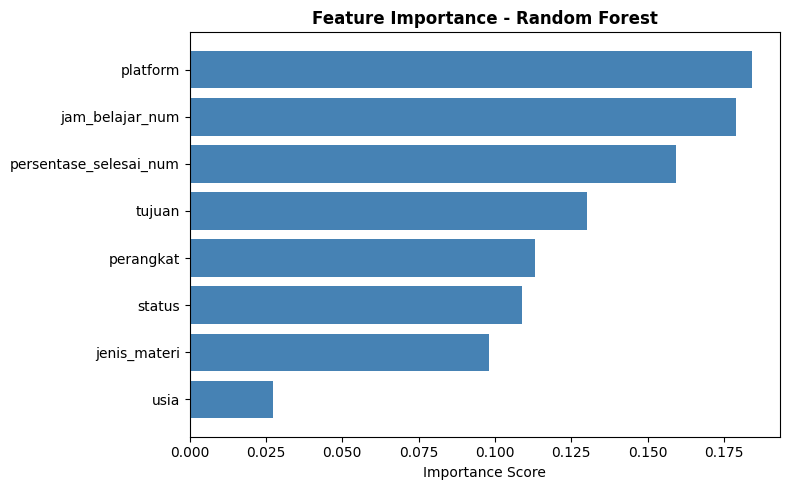

In [15]:
feat_names = fitur_kategori + fitur_numerik
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({'Fitur': feat_names, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp['Fitur'], feat_imp['Importance'], color='steelblue')
plt.title('Feature Importance - Random Forest', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Prediksi Data Baru

| Kolom | Pilihan Nilai |
|---|---|
| `usia` | `'18–24 tahun'` · `'25–34 tahun'` |
| `status` | `'Mahasiswa/pelajar'` · `'Pekerja profesional'` · `'Freelancer'` |
| `platform` | `'YouTube'` · `'Udemy'` · `'Coursera'` · `'Dicoding'` · `'Khan Academy'` · `'edX'` · `'Skillshare'` · `'Ruang Guru'` |
| `perangkat` | `'Laptop'` · `'HP / Mobile'` · `'Desktop / PC'` · `'Tablet'` |
| `jam_belajar_num` | `0.5` · `2.0` · `5.0` · `8.5` · `13.0` · `18.0` · `22.0` |
| `tujuan` | `'Keperluan akademik'` · `'Upgrade skill'` · `'Pengembangan karier'` · `'Hobi / minat pribadi'` |
| `jenis_materi` | `'Video'` · `'Teks / artikel / modul'` · `'Campuran keduanya'` |
| `persentase_selesai_num` | `10` · `30` · `50` · `70` · `90` |

In [16]:
data_baru = {
    'usia'                  : '18–24 tahun',          # usia responden
    'status'                : 'Mahasiswa/pelajar',   # status saat ini
    'platform'              : 'YouTube',             # platform belajar
    'perangkat'             : 'Laptop',              # perangkat yang digunakan
    'jam_belajar_num'       : 13.0,                   # jam belajar/minggu (4-6 jam = 5.0)
    'tujuan'                : 'Keperluan akademik',  # tujuan belajar
    'jenis_materi'          : 'Video',               # jenis materi
    'persentase_selesai_num': 50                     # % materi selesai (61-80% = 70)
}
# ================================================================

def encode_input(data, encoders, fitur_kategori, fitur_numerik):
    """Encode input dict menjadi array numerik untuk prediksi."""
    row = []
    for col in fitur_kategori:
        le = encoders[col]
        val = data[col]
        if val not in le.classes_:
            print(f'PERINGATAN: Nilai "{val}" tidak dikenal untuk kolom "{col}"')
            print(f'  Pilihan valid: {list(le.classes_)}')
            return None
        row.append(le.transform([val])[0])
    for col in fitur_numerik:
        row.append(data[col])
    return np.array(row).reshape(1, -1)

X_baru = encode_input(data_baru, encoders, fitur_kategori, fitur_numerik)

if X_baru is not None:
    print('=' * 50)
    print('  DATA BARU YANG DIINPUT')
    print('=' * 50)
    for k, v in data_baru.items():
        print(f'  {k:30s}: {v}')
    print('=' * 50)
    print()

    model_list = {
        'Decision Tree'       : dt_model,
        f'KNN (K={best_k})'   : knn_model,
        'Random Forest'       : rf_model,
        'Naive Bayes'         : nb_model,
    }

    print('HASIL PREDIKSI:')
    print('-' * 50)
    for nama, model in model_list.items():
        pred = le_target.inverse_transform(model.predict(X_baru))[0]
        if hasattr(model, 'predict_proba'):
            proba = model.predict_proba(X_baru)[0]
            proba_str = '  |  '.join([f'{c}: {p*100:.1f}%'
                                      for c, p in zip(le_target.classes_, proba)])
            print(f'  {nama:22s} => {pred:8s}  [{proba_str}]')
        else:
            print(f'  {nama:22s} => {pred}')
    print('-' * 50)

  DATA BARU YANG DIINPUT
  usia                          : 18–24 tahun
  status                        : Mahasiswa/pelajar
  platform                      : YouTube
  perangkat                     : Laptop
  jam_belajar_num               : 13.0
  tujuan                        : Keperluan akademik
  jenis_materi                  : Video
  persentase_selesai_num        : 50

HASIL PREDIKSI:
--------------------------------------------------
  Decision Tree          => Sedang    [Rendah: 0.0%  |  Sedang: 61.5%  |  Tinggi: 38.5%]
  KNN (K=13)             => Sedang    [Rendah: 7.7%  |  Sedang: 76.9%  |  Tinggi: 15.4%]
  Random Forest          => Sedang    [Rendah: 1.7%  |  Sedang: 58.6%  |  Tinggi: 39.7%]
  Naive Bayes            => Sedang    [Rendah: 12.1%  |  Sedang: 47.2%  |  Tinggi: 40.7%]
--------------------------------------------------


## 10. Kesimpulan

Notebook ini melakukan klasifikasi **tingkat kepuasan pengguna** (`Rendah` / `Sedang` / `Tinggi`) terhadap platform belajar online menggunakan data survei mahasiswa.

---

### 📊 Hasil Perbandingan Akurasi Model

| Model | Keterangan |
|---|---|
| **Random Forest** | Konsisten & stabil — direkomendasikan untuk prediksi data baru |
| **Decision Tree** | Aturan jelas, mudah diinterpretasi, cocok untuk dataset kecil |
| **KNN** | Akurasi CV tinggi, namun kurang optimal untuk data baru bertipe kategorikal |
| **Naive Bayes** | Cepat & ringan, cocok sebagai baseline pembanding |

---

### 🔍 Mengapa KNN Bagus di Evaluasi tapi DT/RF Lebih Andal di Prediksi?

KNN bekerja dengan mencari tetangga terdekat dari data training (tidak membangun aturan). Performanya bagus saat cross-validation karena "mengenal" data training, namun kurang optimal untuk data baru karena:

- Dataset survei ini **dominan fitur kategorikal** (`platform`, `perangkat`, `tujuan`, dll.) yang di-encode menjadi angka. KNN menghitung jarak Euclidean antar angka encode, padahal angka tersebut tidak memiliki makna urutan/jarak yang sesungguhnya.
- **Ukuran dataset kecil** membuat penghitungan tetangga terdekat menjadi kurang representatif untuk titik data baru.

Decision Tree dan Random Forest membangun **aturan keputusan dari pola data**, sehingga lebih robust saat menghadapi data baru yang belum pernah dilihat sebelumnya.

---

### 💡 Fitur Berpengaruh

Berdasarkan grafik *Feature Importance* Random Forest, fitur yang paling berpengaruh terhadap kepuasan adalah **tingkat kepuasan numerik (skor 1–10)**, diikuti oleh **persentase materi yang diselesaikan** dan **jam belajar per minggu**.

---